# Đề 3: Random Forest Classifier
###  Phân loại Rượu vang: 
### 1 Tải bộ dữ liệu Wine từ Scikit-Learn. In ra shape của tập dữ liệu (X và y).
### 2 Chia dữ liệu thành tập huấn luyện (70%) và tập kiểm tra (30%).
### 3 Áp dụng và huấn luyện thuật toán Random Forest Classifier với n_estimators=100.
### 4 Tính toán và hiển thị Báo cáo phân loại (Classification Report) trên tập kiểm tra.
### 5 Trực quan hóa Tầm quan trọng của Đặc trưng (Feature Importance) dưới dạng biểu đồ cột.


## 1 - Gọi thư viện 

In [18]:
import pandas as pd 
from sklearn.datasets import load_wine 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split

## 2 - Hiển thị thông tin 

In [19]:
du_lieu = load_wine()
df = pd.DataFrame(du_lieu.data, columns= du_lieu.feature_names)
X = du_lieu.data 
y = du_lieu.target
print("In 5 dong đầu dữ liệu:\n ", df.head()) 
print("Thông tin dữ liệu : \n", df.info())
print("Mô tả thống kê dữ liệu: \n", df.describe())

In 5 dong đầu dữ liệu:
     alcohol  malic_acid   ash  ...   hue  od280/od315_of_diluted_wines  proline
0    14.23        1.71  2.43  ...  1.04                          3.92   1065.0
1    13.20        1.78  2.14  ...  1.05                          3.40   1050.0
2    13.16        2.36  2.67  ...  1.03                          3.17   1185.0
3    14.37        1.95  2.50  ...  0.86                          3.45   1480.0
4    13.24        2.59  2.87  ...  1.04                          2.93    735.0

[5 rows x 13 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium     

## 3 - Chia tập dữ liệu train test 

In [20]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state= 42, stratify=y)
bo_chuan_hoa = StandardScaler()
x_train = bo_chuan_hoa.fit_transform(x_train)
x_test = bo_chuan_hoa.transform(x_test)
print("Chia train test thành công ")

Chia train test thành công 


## 4 - Huấn luyện mô hình 

In [21]:
mo_hinh = RandomForestClassifier(n_estimators=100)
mo_hinh.fit(x_train, y_train)
du_doan = mo_hinh.predict(x_test)
print("Huấn luyên thành công mô hình")

Huấn luyên thành công mô hình


## 5 - Tính toán và hiển thị báo cáo 

In [25]:
bao_cao = classification_report(y_test, du_doan,target_names=du_lieu.target_names)
print("Báo cáo phân loại : \n", bao_cao)


Báo cáo phân loại : 
               precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



## 6 - Trực quan tầm quan trọng - vẽ biểu đồ 

In [ ]:
# Tạo bảng
do_quan_trong = mo_hinh.feature_importances_
dac_trung  = du_lieu.feature_names
table = pd.DataFrame({"Đặc trưng":dac_trung, "Độ quan trọng" : do_quan_trong})
table = table.sort_values(by="Độ quan trọng", ascending= False)
print(table)

                       Đặc trưng  Độ quan trọng
9                color_intensity       0.197032
6                     flavanoids       0.165432
0                        alcohol       0.144037
12                       proline       0.138898
11  od280/od315_of_diluted_wines       0.109899
10                           hue       0.060399
5                  total_phenols       0.053828
1                     malic_acid       0.033249
3              alcalinity_of_ash       0.025495
4                      magnesium       0.025190
8                proanthocyanins       0.019180
7           nonflavanoid_phenols       0.015681
2                            ash       0.011680


<function matplotlib.pyplot.show(close=None, block=None)>

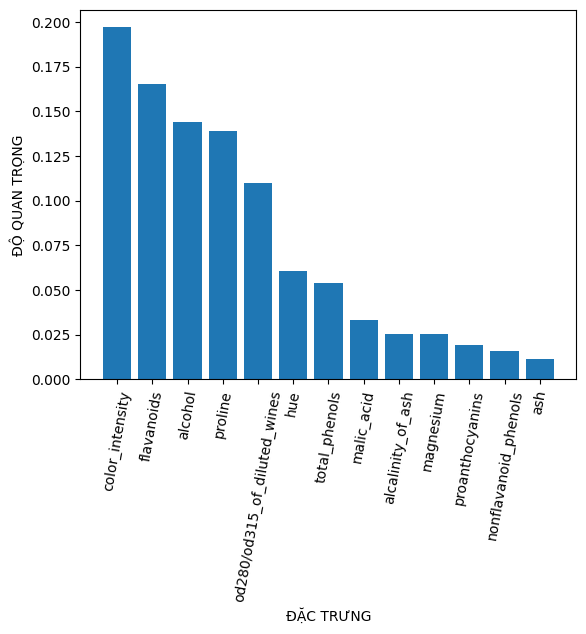

In [36]:
# Vẽ biểu đồ: 
plt.bar(table["Đặc trưng"], table["Độ quan trọng"])
plt.Figure(figsize=(10,5))
plt.xticks(rotation= 80)
plt.xlabel("ĐẶC TRƯNG")
plt.ylabel("ĐỘ QUAN TRỌNG")
plt.show